# Forecasting International Student Mobility

**Group 26:** Adriano Machado, Francisco da Ana, João Lopes, Tiago Teixeira

ESN Porto is a non-profit that supports international exchange students in Porto. Students who buy a membership card get discounts at local businesses, invitations to social events, and access to cultural activities.

We analyzed five years of membership data to identify trends and forecast **weekly** sign-ups. Better predictions mean ESN Porto can staff appropriately, having enough volunteers ready when students need help most, and schedule events when demand is highest.


In [39]:
import json
import os
import warnings
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec 
import numpy as np
import pandas as pd
import seaborn as sns

import optuna
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFECV
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.pipeline import make_pipeline


from scipy.stats import boxcox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings('ignore')

In [40]:
DATA_DIR = Path('data')
FIGURES_DIR = Path('figures')
RESULTS_DIR = Path('results')
FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# Configuration: Set to True to run hyperparameter tuning, False to load from saved results
RUN_HYPERPARAMETER_TUNING = True

## Exploratory Data Analysis

In [41]:
data_dir = Path('data')

with open(data_dir / 'eventupp_students_private.json', 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data)
df['registerDate_dt'] = pd.to_datetime(df['registerDate'], unit='ms')
df = df.sort_values('registerDate_dt')

print(f"Total students: {len(df):,}")
print(f"Academic years: {sorted(df['academic_year'].unique())}")
print(f"Date range: {df['registerDate_dt'].min()} to {df['registerDate_dt'].max()}")


Total students: 14,168
Academic years: ['2021_2022', '2022_2023', '2023_2024', '2024_2025', '2025_2026']
Date range: 2021-08-03 12:10:42.923000 to 2025-12-02 14:34:00.471000


In [42]:
df.head(2)

,gender,birthdate,country,organization,university,registerDate,program,programDuration,academic_year,registerDate_dt
0,female,980347260000,Poland,5f1ebfbc2fd6333295e8e9af,Universidade do Porto (UP) - Faculdade de Letr...,1627992642923,Erasmus + Programme: study exchange,4-6 months (1 Semester),2021_2022,2021-08-03 12:10:42.923
1,female,895764420000,Germany,5f1ebfbc2fd6333295e8e9af,Instituto Politécnico do Porto - Instituto Sup...,1627992763121,Erasmus + Programme: study exchange,4-6 months (1 Semester),2021_2022,2021-08-03 12:12:43.121


The dataset contains 9 variables describing each membership registration, which can be categorized as follows:

- Temporal: Registration Date (Timestamp).
- Demographic: Age (derived from birthdate), Gender, and Country of origin.
- Academic: University (e.g., U.Porto, IPP), Program Type (Erasmus, Exchange, Volunteer), and Program Duration.

The data was collected between September 2021 and December 2025

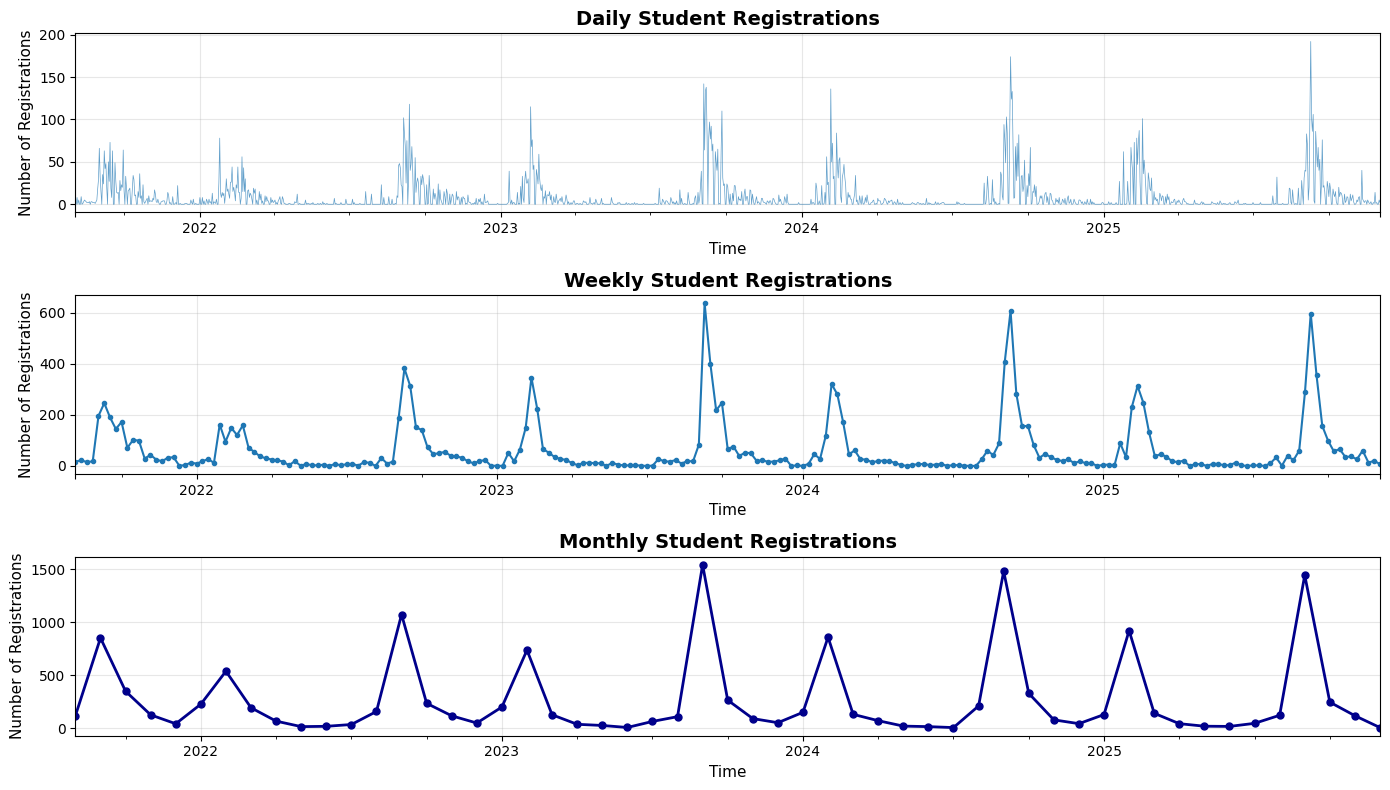

In [43]:
daily_counts = df.groupby(df['registerDate_dt'].dt.date).size()
fig = plt.figure(figsize=(14, 8))

# Plot 1: Daily registrations
daily_ts = pd.Series(daily_counts.values, index=pd.to_datetime(daily_counts.index))
daily_ts = daily_ts.asfreq('D', fill_value=0)  

ax1 = plt.subplot(3, 1, 1)
daily_ts.plot(ax=ax1, linewidth=0.5, alpha=0.7)
ax1.set_title('Daily Student Registrations', fontsize=14, fontweight='bold')
ax1.set_xlabel('Time', fontsize=11)
ax1.set_ylabel('Number of Registrations', fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Weekly registrations
weekly_ts = daily_ts.resample('W').sum()
ax2 = plt.subplot(3, 1, 2)
weekly_ts.plot(ax=ax2, linewidth=1.5, marker='o', markersize=3)
ax2.set_title('Weekly Student Registrations', fontsize=14, fontweight='bold')
ax2.set_xlabel('Time', fontsize=11)
ax2.set_ylabel('Number of Registrations', fontsize=11)
ax2.grid(True, alpha=0.3)

# Plot 3: Monthly registrations
monthly_ts = daily_ts.resample('ME').sum()
ax3 = plt.subplot(3, 1, 3)
monthly_ts.plot(ax=ax3, linewidth=2, marker='o', markersize=5, color='darkblue')
ax3.set_title('Monthly Student Registrations', fontsize=14, fontweight='bold')
ax3.set_xlabel('Time', fontsize=11)
ax3.set_ylabel('Number of Registrations', fontsize=11)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Since the raw data is recorded as timestamps, we have the flexibility to aggregate the time series at any resolution.
- Daily frequency is very noisy, with most days recording zero registrations interrupted by extreme spikes during
semester starts. 

- Monthly aggregation provided the cleanest seasonal signal but
sacrificed temporal detail. 

We choose **weekly frequency** as a balance between noise reduction and temporal resolution.

In [44]:
# Convert registerDate from milliseconds to datetime
df['registerDate'] = pd.to_datetime(df['registerDate'], unit='ms')
df_ts = df.set_index('registerDate').sort_index()

# Aggregate weekly - count registrations per week
weekly_registrations = df_ts.resample('W').size()

# Create a DataFrame with weekly aggregation
weekly_df = pd.DataFrame({
    'week_ending': weekly_registrations.index,
    'registrations': weekly_registrations.values
})

In [45]:
weekly_ts.head()

registerDate_dt
2021-08-08     17
2021-08-15     22
2021-08-22     15
2021-08-29     18
2021-09-05    196
Freq: W-SUN, dtype: int64

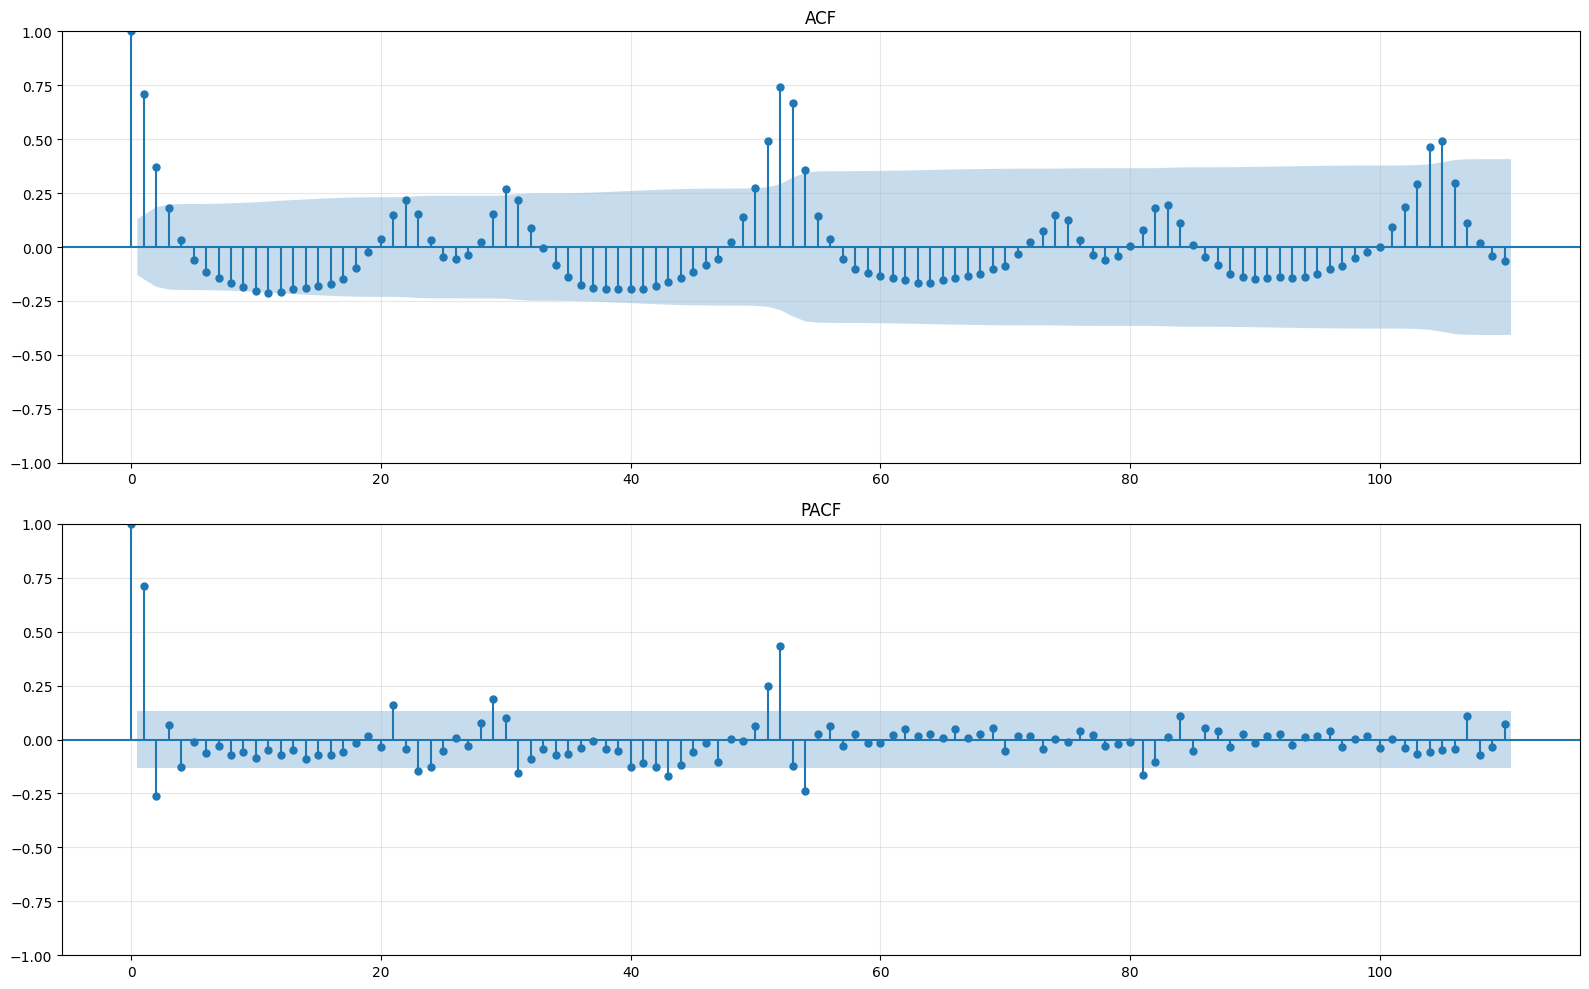

In [46]:
y = weekly_ts.fillna(0)
target_lags = 110

max_pacf_lags = max(1, min(target_lags, len(y) // 2 - 1))
max_acf_lags = target_lags

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

plot_acf(y, lags=max_acf_lags, ax=axes[0])
axes[0].set_title(f'ACF')
axes[0].grid(alpha=0.3, axis='both') 

plot_pacf(y, lags=max_pacf_lags, ax=axes[1], method='ywm')
axes[1].set_title(f'PACF')
axes[1].grid(alpha=0.3, axis='both')

plt.tight_layout()
plt.show()

1.  **Strong Annual Seasonality:** The ACF shows a peak at **Lag 52**, confirming that student registrations follow a predictable yearly cycle.
2.  **Non-Stationarity:** The slow decay in the ACF plot indicates the data is non-stationary, meaning the mean and variance change over time (driven by the seasonality).
3.  **Short-Term Dependency:** The PACF shows sharp spikes at **Lags 1 and 2**, suggesting that the number of registrations in a given week is strongly predicted by the activity in the two weeks prior.

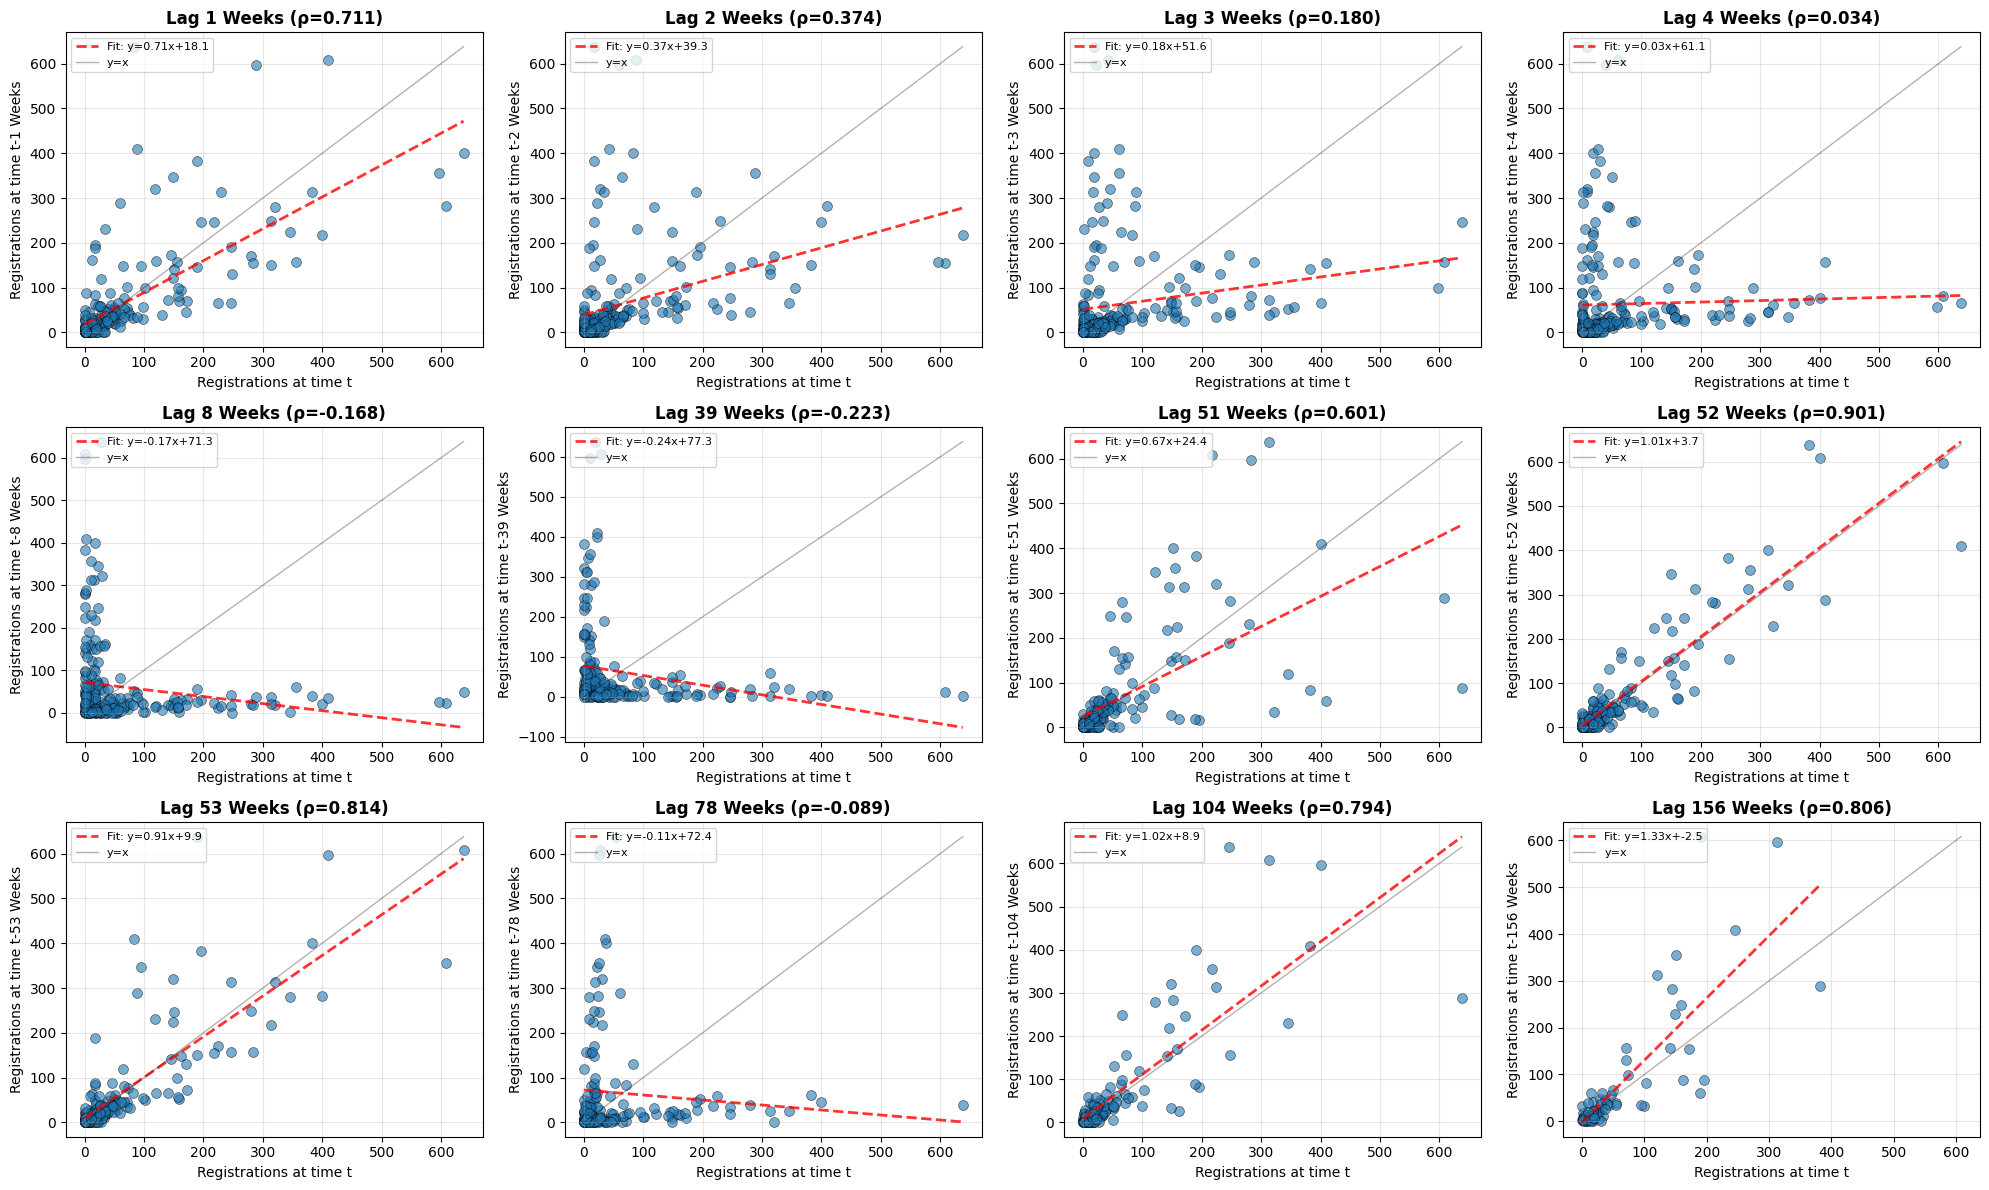

In [47]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

lags_to_plot = [1, 2, 3, 4, 8, 39, 51, 52, 53, 78, 52*2, 52*3]

for i, lag in enumerate(lags_to_plot):
    ax = axes[i]
    
    y = weekly_ts.values[lag:]
    x = weekly_ts.values[:-lag]
    
    ax.scatter(x, y, alpha=0.6, s=50, edgecolors='black', linewidths=0.5)
        
    if len(x) > 1:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        
        # Create a sorted range of X values for a clean line plot
        x_line = np.linspace(x.min(), x.max(), 100)
        
        # Plot using the sorted range
        ax.plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.8, label=f'Fit: y={z[0]:.2f}x+{z[1]:.1f}')
    
    corr = weekly_ts.autocorr(lag=lag)
    
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, 'k-', alpha=0.3, linewidth=1, label='y=x')
    
    ax.set_title(f'Lag {lag} Weeks (ρ={corr:.3f})', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'Registrations at time t')
    ax.set_ylabel(f'Registrations at time t-{lag} Weeks')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

First lets analyze the autocorrelation values:

- **Lag 1**: Strong and positive, which might indicate that a week's registration volume is highly influenced by the previous week.
- **Lag 2, 3, 4**: The correlations drops quickly, being almost 0 by lag 4, meaning that the volume of the previous month has little to no influence on the current week's registrations.
- **Lag 52**: Very strong positive correlation, confirming the annual seasonality where registrations in a given week are highly predictive of the same week in the previous year.
- **Lag 104, 156**: The correlations remain strong, highlighting the multi-year consistency of the seasonal pattern.
- **Lag 8, 39, 78**: No significant half-year correlations.

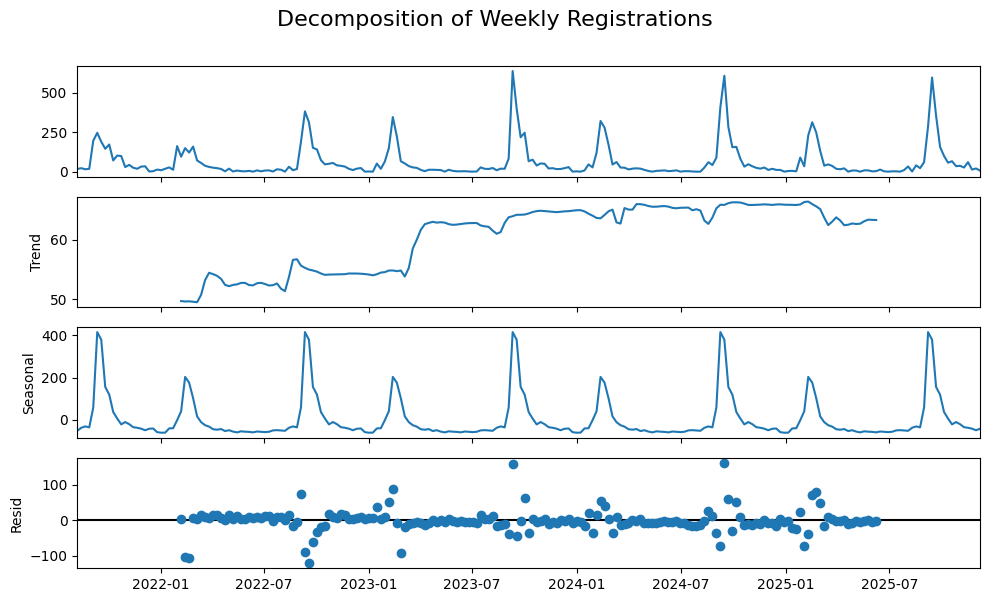

In [48]:
# Decompose the series (Additive model assumed initially)
# period=52 for weekly data with annual cycle
decomposition = seasonal_decompose(weekly_ts, model='additive', period=52)

fig = decomposition.plot()
fig.set_size_inches(10, 6)
plt.suptitle('Decomposition of Weekly Registrations', fontsize=16, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()

* **Trend:** Recovering from the pandemic, registrations increased until mid-2023, after which the trend plateaued.
* **Seasonality:** The data has a bi-annual cycle with primary peaks in September and secondary peaks in February, corresponding to the start of academic semesters. 
* **Residuals:** For the most part, residuals hover around zero, indicating the seasonal+trend model explains the movements well. However, there are occasional positive outliers particularly around february and august (between semesters)


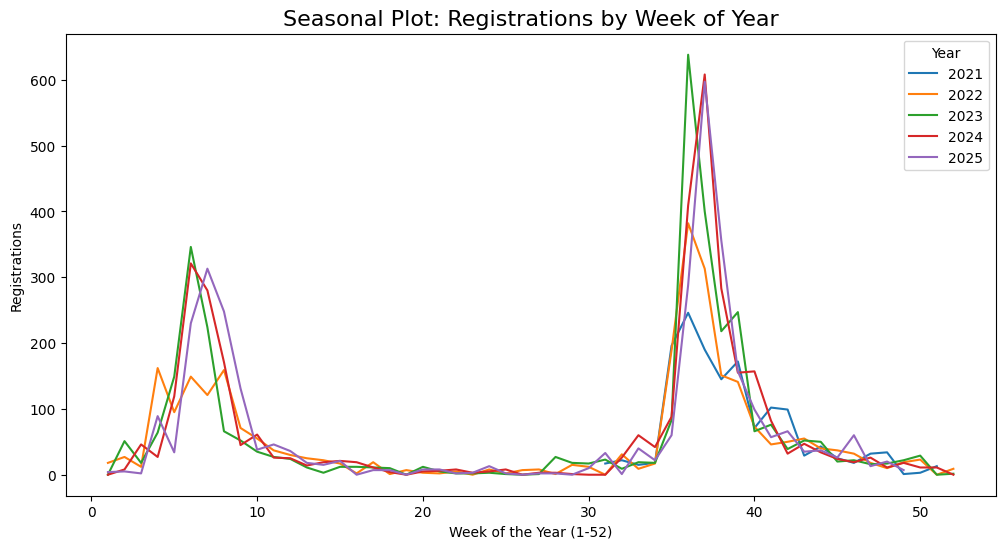

In [49]:
# Prepare data for seasonal plot
df['date'] = pd.to_datetime(df['registerDate'], unit='ms')
weekly_ts = df.set_index('date').resample('W').size()
df_seasonal = pd.DataFrame({'counts': weekly_ts})
df_seasonal['week'] = df_seasonal.index.isocalendar().week
df_seasonal['year'] = df_seasonal.index.year

# Plot overlapping years
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_seasonal, x='week', y='counts', hue='year', palette='tab10')
plt.title('Seasonal Plot: Registrations by Week of Year', fontsize=16)
plt.xlabel('Week of the Year (1-52)')
plt.ylabel('Registrations')
plt.legend(title='Year')
plt.show()

As we can see in seasonal plot there's a clear pattern in student registrations, especially in the last years (2023/2024/2025) after the recovery from the pandemic.

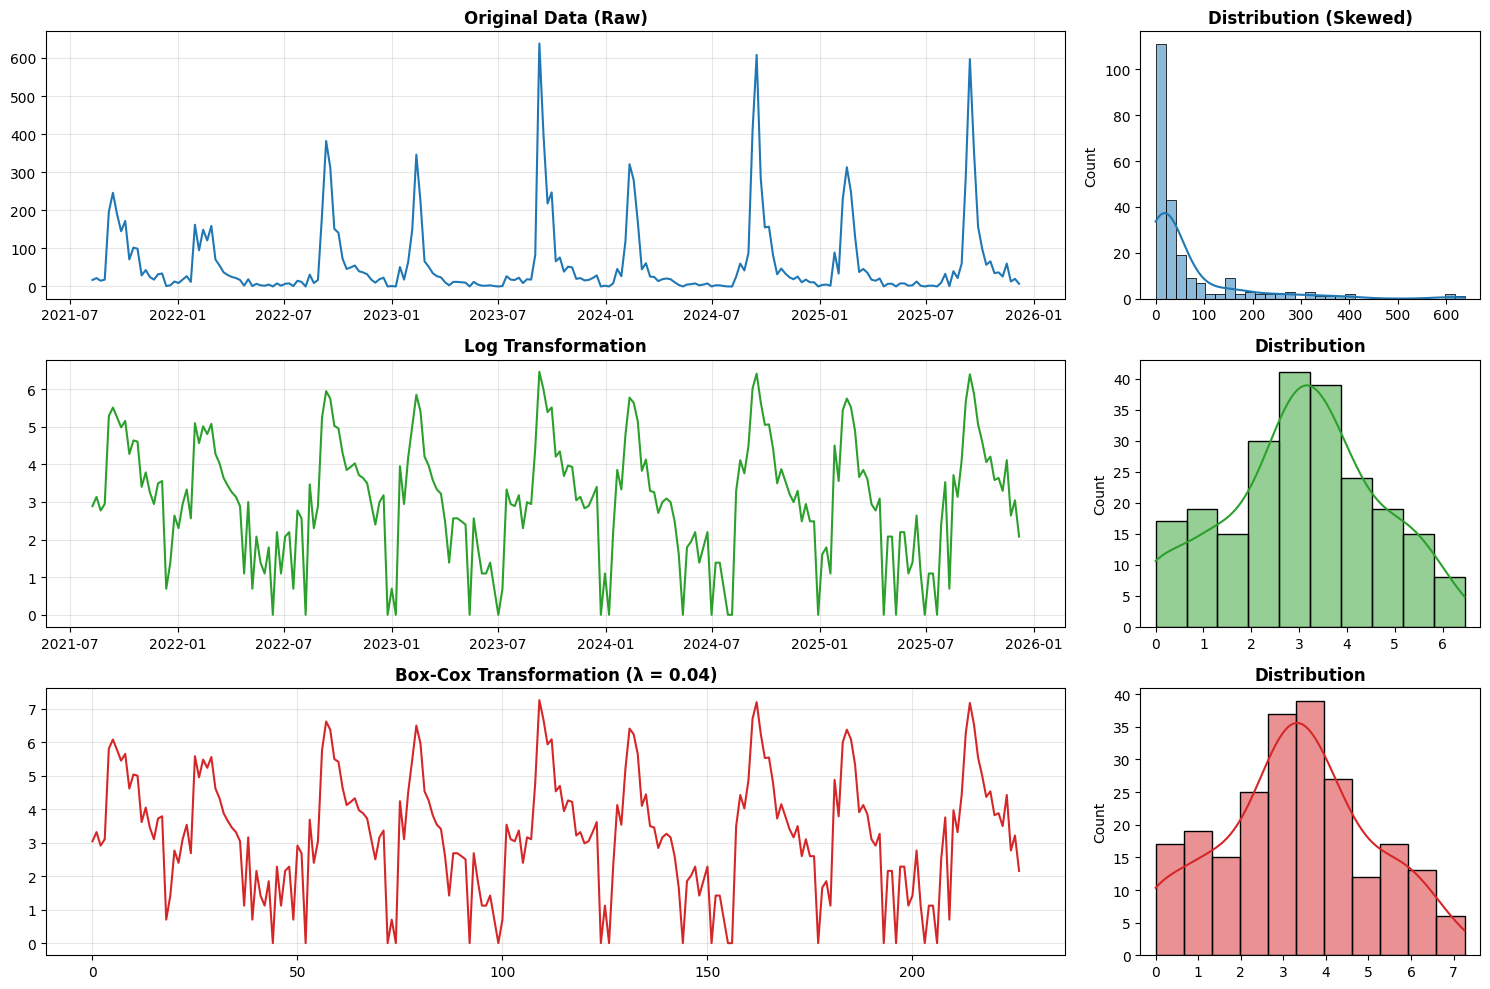

In [50]:
y_raw = weekly_ts.copy()
offset = 1 
y_positive = y_raw + offset

# Log Transformation
y_log = np.log(y_positive)

# Box-Cox Transformation
y_boxcox, best_lambda = boxcox(y_positive)

# Plots
fig = plt.figure(figsize=(15, 10))
gs = GridSpec(3, 2, figure=fig, width_ratios=[3, 1])

# Original
ax_ts1 = fig.add_subplot(gs[0, 0])
ax_dist1 = fig.add_subplot(gs[0, 1])
ax_ts1.plot(y_raw, color='tab:blue')
ax_ts1.set_title('Original Data (Raw)', fontweight='bold')
ax_ts1.grid(True, alpha=0.3)
sns.histplot(y_raw, ax=ax_dist1, color='tab:blue', kde=True)
ax_dist1.set_title('Distribution (Skewed)', fontweight='bold')

# Log transformation
ax_ts2 = fig.add_subplot(gs[1, 0])
ax_dist2 = fig.add_subplot(gs[1, 1])
ax_ts2.plot(y_log, color='tab:green')
ax_ts2.set_title('Log Transformation', fontweight='bold')
ax_ts2.grid(True, alpha=0.3)
sns.histplot(y_log, ax=ax_dist2, color='tab:green', kde=True)
ax_dist2.set_title('Distribution', fontweight='bold')

# Box-Cox transformation
ax_ts3 = fig.add_subplot(gs[2, 0])
ax_dist3 = fig.add_subplot(gs[2, 1])
ax_ts3.plot(y_boxcox, color='tab:red')
ax_ts3.set_title(f'Box-Cox Transformation (λ = {best_lambda:.2f})', fontweight='bold')
ax_ts3.grid(True, alpha=0.3)
sns.histplot(y_boxcox, ax=ax_dist3, color='tab:red', kde=True)
ax_dist3.set_title('Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

- **Original data is right-skewed** - The distribution shows most values clustered near zero with occasional large spikes (visible in the time series).

- **Both transformations reduce skewness** - Log and Box-Cox transformations both normalize the distribution significantly, making it more bell-shaped and closer to normal.

- **Box-Cox (λ = 0.04) ≈ Log transformation** - Since λ is very close to 0, the Box-Cox transformation is essentially equivalent to a log transform (when λ=0, Box-Cox becomes log). This is why both the time series patterns and distributions look nearly identical.

- **Stabilizes variance** - The transformations reduce the amplitude of spikes in the time series, making variance more consistent over time (important for many statistical models).

## Modeling Strategy

Our time series is characterized by high seasonal peaks, intermediated by near-zero values (corresponding to the course of the semester). This led us to explore alternative methods for time-series prediction. There are some similarities between our problem and that of "Sales Forecasting in Fast Fashion Industry", by Inês Gonçalves Vieira, where the data follows a similar behaviour.

Inspired on the metholody proposed in this thesis, our strategy consists in **transforming the prediction task into a regression problem** that can be solved using machine learning models.

In order to follow this approach, there are some questions that we need to adress first:
- How can we evaluate the predictions?
- What are the features that we'll give as input to the models?
- What are the models that we can test and with which parameters?


### Error Metric

To evaluate the quality of our predictions, we track the following metrics:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Weighted Mean Absolute Percentage Error (WMAPE)

From these metrics, we will focus on minimizing the RMSE, as it penalizes larger errors more heavily, which is important given the peaky nature of our data.

### Feature Engineering

There's usually a tradeoff between the number of features that the model receives as input and its performance. Too many features may lead to noisy predictions, so the challenge of this step is to a find a concise subset of variables that are relevant for forecasting and can guide the model's ability.

In order to discover the optimal subset in an unbiased way, we performed **Recursive Feature Elimination (RFE)**, a greedy optimization technique that repeatidly fits a model eliminating the weakest features.

In total, we considered the following features:
- month
- year
- week of year
- day of month
- week of month
- is welcome month?
- semester
- week of semester
- sin and cos of week of year
- lags: 1,2,52
- mean and standard deviation of last 4 weeks

In [51]:
def create_features(df):
    df = df.copy()

    df['month'] = df['week_ending'].dt.month
    df['year'] = df['week_ending'].dt.year
    df['week_of_year'] = df['week_ending'].dt.isocalendar().week.astype(int)

    # Calculate week of month (0-5)
    df['day_of_month'] = df['week_ending'].dt.day
    df['week_of_month'] = ((df['day_of_month'] - 1) // 7)

    # Is welcome month (February=2 or September=9)
    df['is_welcome_month'] = ((df['week_ending'].dt.month == 2) | (df['week_ending'].dt.month == 9)).astype(int)

    # Semester: 0 for fall (Aug-Jan), 1 for spring (Feb-Jul)
    df['semester'] = ((df['week_ending'].dt.month >= 2) & (df['week_ending'].dt.month <= 7)).astype(int)

    # Week of semester calculation
    def calculate_week_of_semester(row):
        year = row['year']
        month = row['month']
        week_ending = row['week_ending']

        if month >= 8:  # Fall semester (Aug-Dec)
            semester_start = pd.Timestamp(year=year, month=8, day=1)
        elif month <= 7 and month >= 2:  # Spring semester (Feb-Jul)
            semester_start = pd.Timestamp(year=year, month=2, day=1)
        else:  # January (still fall semester of previous academic year)
            semester_start = pd.Timestamp(year=year-1, month=8, day=1)

        weeks_diff = (week_ending - semester_start).days // 7
        return max(0, weeks_diff)

    df['week_of_semester'] = df.apply(calculate_week_of_semester, axis=1)
    df['week_sin'] = np.sin(2 * np.pi * df['week_of_year'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['week_of_year'] / 52)

    # Lag features
    for lag in [1, 2, 52]: 
        df[f'lag_abs_{lag}'] = df['registrations'].shift(lag)

    df['roll_mean_4_abs'] = df['registrations'].shift(1).rolling(window=4).mean() 
    df['roll_std_4_abs']  = df['registrations'].shift(1).rolling(window=4).std()  

    return df

df_features = create_features(weekly_df)
print(f"Features created: {df_features.shape[1]}")
df_features.head()

Features created: 17


,week_ending,registrations,month,year,week_of_year,day_of_month,week_of_month,is_welcome_month,semester,week_of_semester,week_sin,week_cos,lag_abs_1,lag_abs_2,lag_abs_52,roll_mean_4_abs,roll_std_4_abs
0,2021-08-08,17,8,2021,31,8,1,0,0,1,-0.568065,-0.822984,NaN,NaN,NaN,NaN,NaN
1,2021-08-15,22,8,2021,32,15,2,0,0,2,-0.663123,-0.748511,17.0,NaN,NaN,NaN,NaN
2,2021-08-22,15,8,2021,33,22,3,0,0,3,-0.748511,-0.663123,22.0,17.0,NaN,NaN,NaN
3,2021-08-29,18,8,2021,34,29,4,0,0,4,-0.822984,-0.568065,15.0,22.0,NaN,NaN,NaN
4,2021-09-05,196,9,2021,35,5,0,1,0,5,-0.885456,-0.464723,18.0,15.0,NaN,18.0,2.94392


We'll divide our training data into a training (2021-2024) and test set (2025).

In [52]:
df_model = df_features.dropna()

# Split Train (2021-2024) and Test (2025)
train = df_model[df_model['year'] < 2025].copy()
test = df_model[df_model['year'] == 2025].copy()

target = 'registrations'
drop_cols = [target, 'week_ending'] 

X_train = train.drop(columns=drop_cols)
y_train = train[target]

print(f"Training shapes: X={X_train.shape}, y={y_train.shape}")

Training shapes: X=(126, 15), y=(126,)


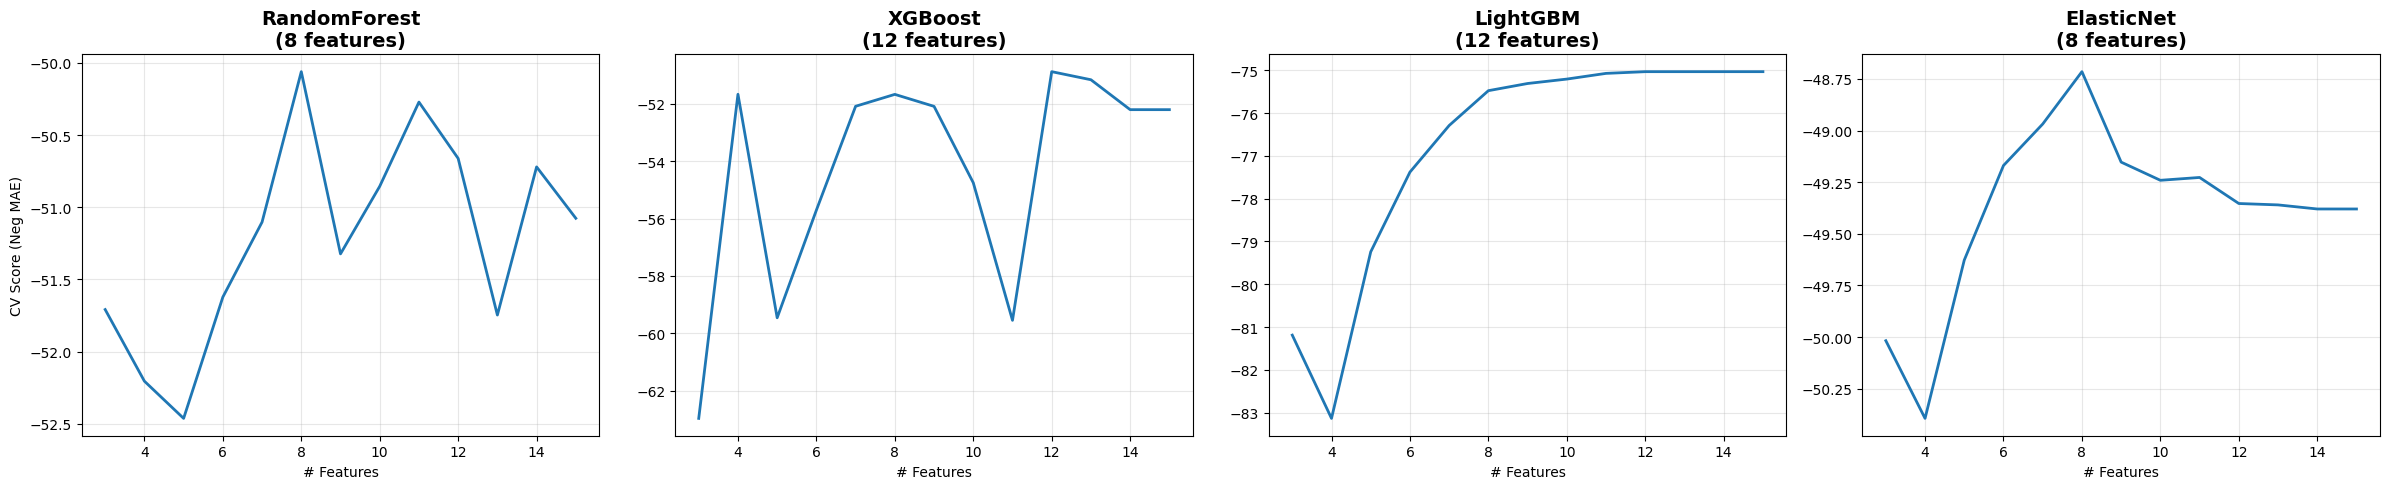

,RandomForest,XGBoost,LightGBM,ElasticNet,Count
day_of_month,1,1,1,1,4
is_welcome_month,1,1,1,1,4
lag_abs_1,1,1,1,1,4
lag_abs_2,1,1,1,1,4
lag_abs_52,1,1,1,1,4
roll_std_4_abs,1,1,1,1,4
week_sin,1,1,1,1,4
roll_mean_4_abs,1,1,1,0,3
week_of_semester,0,1,1,1,3
week_cos,0,1,1,0,2


In [53]:
warnings.filterwarnings("ignore", category=UserWarning, module='sklearn.utils.validation')
warnings.filterwarnings("ignore", category=FutureWarning)

models_to_test = {
    'RandomForest': RandomForestRegressor(n_jobs=-1, random_state=42),
    'XGBoost': XGBRegressor(objective='reg:absoluteerror', n_jobs=-1, random_state=42),
    'LightGBM': LGBMRegressor(n_jobs=-1, random_state=42, verbose=-1),
    'ElasticNet': ElasticNet(random_state=42, max_iter=10000)
}

final_selections = {}
tscv = TimeSeriesSplit(n_splits=5)

fig, axes = plt.subplots(1, 4, figsize=(24, 5)) 


for i, (name, model) in enumerate(models_to_test.items()):    
    if name == 'ElasticNet':
        scaler = StandardScaler()
        X_used = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
        model = ElasticNet(random_state=42, max_iter=10000)
    else:
        X_used = X_train

    selector = RFECV(
        estimator=model,
        step=1,
        cv=tscv,
        scoring='neg_root_mean_squared_error',
        min_features_to_select=3
    )
    selector = selector.fit(X_used, y_train)

    selected_features = X_train.columns[selector.support_].tolist()
    final_selections[name] = selected_features

    ax = axes[i]
    x_points = range(3, len(selector.cv_results_['mean_test_score']) + 3)
    y_points = selector.cv_results_['mean_test_score']
    
    ax.plot(x_points, y_points, linewidth=2, color='tab:blue')
    
    ax.set_title(f'{name}\n({len(selected_features)} features)', fontsize=14, fontweight='bold')
    ax.set_xlabel("# Features")
    if i == 0: ax.set_ylabel("CV Score (Neg MAE)") 
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

all_features = sorted(list(set(x for l in final_selections.values() for x in l)))
selection_df = pd.DataFrame(index=all_features)

for name, features in final_selections.items():
    selection_df[name] = selection_df.index.isin(features).astype(int)

selection_df['Count'] = selection_df.sum(axis=1)
selection_df = selection_df.sort_values('Count', ascending=False)

display(selection_df.style.background_gradient(cmap='Blues', subset=['Count']))

Different models converge to optimal performance with varying feature counts: RandomForest (8), XGBoost (12), LightGBM (12), and ElasticNet (8)

### Model Comparison and Hyperparameter Tuning

To evaluate our models, we adopted a **walk-forward cross-validation** strategy. Given that student registration data is inherently sequential, standard randomized k-fold cross-validation would violate temporal dependencies and cause data leakage by using "future" information to predict the past. This approach is the one that better simulates a realistic environment for real use.

In [54]:
def walk_forward_validation(train_df, test_df, model, feature_cols, target_col='registrations', forecast_horizon=1):
    results = []
    
    relevant_cols = feature_cols + [target_col, 'week_ending']
    train_subset = train_df[relevant_cols].copy()
    test_subset = test_df[relevant_cols].copy()

    test_weeks = test_subset['week_ending'].values
    n_test = len(test_weeks)
    
    current_train = train_subset.copy()
    
    i = 0
    fold = 0

    while i < n_test:
        fold += 1
        end_idx = min(i + forecast_horizon, n_test)
        forecast_weeks = test_weeks[i:end_idx]

        X_train = current_train[feature_cols]
        y_train = current_train[target_col]
        
        current_test_window = test_subset[test_subset['week_ending'].isin(forecast_weeks)]
        X_test = current_test_window[feature_cols]
        y_test = current_test_window[target_col]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        y_pred = np.maximum(0, np.round(y_pred).astype(int))

        for j, week in enumerate(forecast_weeks):
            results.append({
                'week_ending': pd.Timestamp(week),
                'actual': y_test.iloc[j],
                'predicted': y_pred[j],
                'model': type(model).__name__,
                'fold': fold
            })

        # Add the data we just predicted (expanding window)
        current_train = pd.concat([current_train, current_test_window], ignore_index=True)
        
        i = end_idx

    return pd.DataFrame(results)

In [55]:

def objective(trial, model_name, X, y):
    if model_name == 'RandomForest':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'random_state': 42,
            'n_jobs': -1
        }
        model = RandomForestRegressor(**params)
        
    elif model_name == 'XGBoost':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'objective': 'reg:squarederror',
            'random_state': 42,
            'n_jobs': -1
        }
        model = XGBRegressor(**params)
        
    elif model_name == 'LightGBM':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'num_leaves': trial.suggest_int('num_leaves', 20, 100),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'random_state': 42,
            'n_jobs': -1,
            'verbose': -1
        }
        model = LGBMRegressor(**params)
        
    elif model_name == 'ElasticNet':
        params = {
            'alpha': trial.suggest_float('alpha', 0.001, 10.0, log=True),
            'l1_ratio': trial.suggest_float('l1_ratio', 0.0, 1.0),
            'random_state': 42,
            'max_iter': 10000
        }
        model = ElasticNet(**params)

    tscv = TimeSeriesSplit(n_splits=5)
    scores = []
    
    for train_index, val_index in tscv.split(X):
        X_t, X_v = X.iloc[train_index], X.iloc[val_index]
        y_t, y_v = y.iloc[train_index], y.iloc[val_index]
        
        if model_name == 'ElasticNet':
            scaler = StandardScaler()
            X_t = scaler.fit_transform(X_t)
            X_v = scaler.transform(X_v)

        model.fit(X_t, y_t)
        preds = model.predict(X_v)
        mae = np.mean(np.abs(y_v - preds))
        scores.append(mae)

    return np.mean(scores)


In [56]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

all_results = []
best_params_store = {}
for name in models_to_test.keys():
    features = final_selections[name]
    X_train_fs = X_train[features]
    
    if RUN_HYPERPARAMETER_TUNING:
        study = optuna.create_study(direction='minimize')
        study.optimize(lambda trial: objective(trial, name, X_train_fs, y_train), n_trials=20)
        best_params = study.best_params
    else:
        best_params = {} 
        
    best_params_store[name] = best_params

    if name == 'RandomForest':
        final_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
    elif name == 'XGBoost':
        final_model = XGBRegressor(**best_params, objective='reg:squarederror', random_state=42, n_jobs=-1)
    elif name == 'LightGBM':
        final_model = LGBMRegressor(**best_params, random_state=42, n_jobs=-1, verbose=-1)
    elif name == 'ElasticNet':
        final_model = ElasticNet(**best_params, random_state=42, max_iter=10000)        
        final_model = make_pipeline(StandardScaler(), final_model)

    wf_results = walk_forward_validation(
        train_df=train,
        test_df=test,
        model=final_model,
        feature_cols=features,
        forecast_horizon=1
    )
    
    test_mae = np.mean(np.abs(wf_results['actual'] - wf_results['predicted']))
    
    all_results.append(wf_results)

final_results_df = pd.concat(all_results, ignore_index=True)

In [57]:
def calculate_wmape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

final_results_df['model'] = final_results_df['model'].replace({
    'Pipeline': 'ElasticNet',
})

summary_metrics = final_results_df.groupby('model').apply(
    lambda x: pd.Series({
        'MAE': np.mean(np.abs(x['actual'] - x['predicted'])),
        'RMSE': np.sqrt(np.mean((x['actual'] - x['predicted'])**2)),
        'WMAPE': calculate_wmape(x['actual'], x['predicted'])
    })
).sort_values('RMSE')

styler = summary_metrics.style.format("{:.4f}")
styler.background_gradient(cmap='Greens', subset=['MAE', 'RMSE', 'WMAPE'])
display(styler)

,MAE,RMSE,WMAPE
model,,,
XGBRegressor,21.4694,35.6227,0.3219
ElasticNet,21.4490,39.4045,0.3216
RandomForestRegressor,27.7755,53.5760,0.4165
LGBMRegressor,31.2857,56.2438,0.4691


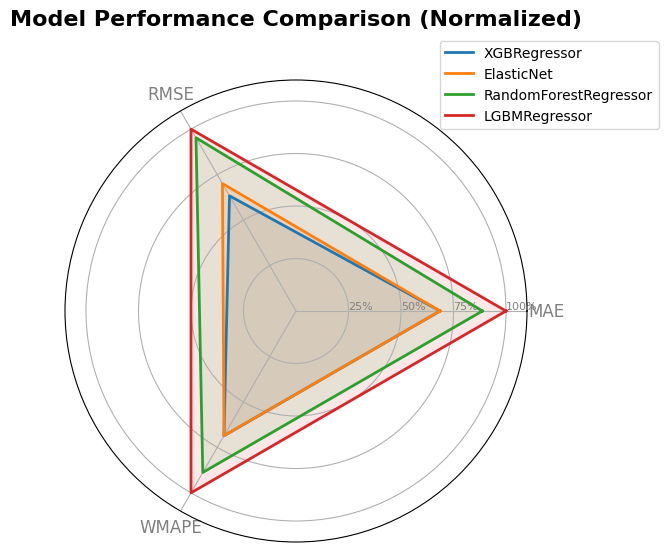

In [61]:
metrics = ['MAE', 'RMSE', 'WMAPE']
num_vars = len(metrics)

labels = summary_metrics.index.tolist()
stats = summary_metrics[metrics].values

max_vals = stats.max(axis=0)
stats_norm = stats / max_vals

stats_norm = np.concatenate((stats_norm, stats_norm[:, [0]]), axis=1)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

plt.xticks(angles[:-1], metrics, color='grey', size=12)

ax.set_rlabel_position(0)
plt.yticks([0.25, 0.5, 0.75, 1.0], ["25%", "50%", "75%", "100%"], color="grey", size=8)
plt.ylim(0, 1.1)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i, model_name in enumerate(labels):
    ax.plot(angles, stats_norm[i], linewidth=2, linestyle='solid', label=model_name, color=colors[i])
    ax.fill(angles, stats_norm[i], color=colors[i], alpha=0.1)

plt.title('Model Performance Comparison (Normalized)', size=16, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

The plot shows that XGBRegressor achieves the best overall performance across RMSE, MAE, and WMAPE compared to the other models.